In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt

In [4]:
df_email = pd.read_csv(r"C:\Users\M USER\Desktop\Projects\Python\CSV Files\spam_or_not_spam.csv")
df = df_email.copy()

In [5]:
df.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [6]:
df.isnull().sum()

email    1
label    0
dtype: int64

In [7]:
df = df.dropna(subset = 'email')
df.isnull().sum()

email    0
label    0
dtype: int64

In [8]:
df.dtypes

email      str
label    int64
dtype: object

In [9]:
df.describe()

,label
count,2999.000000
mean,0.166389
std,0.372491
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


<Axes: xlabel='label'>

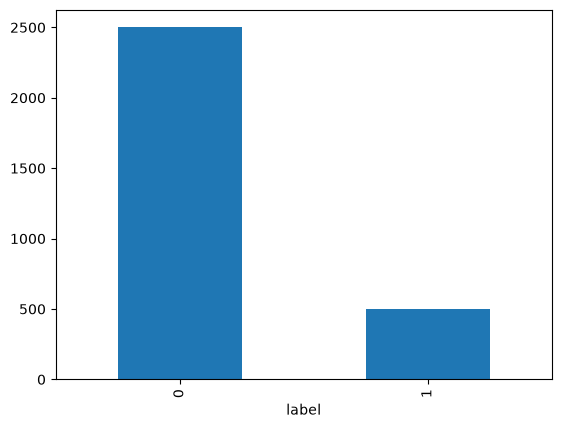

In [10]:
df.value_counts('label').plot(kind = 'bar')

### Very unequal distribution.

In [11]:
print(df.value_counts('label'))
print()
print("Ratio is roughly 1 to 5")

label
0    2500
1     499
Name: count, dtype: int64

Ratio is roughly 1 to 5


In [12]:
X = df['email']
y = df['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

print(f"Size of train set: {X_train.shape[0]}")
print(f"Size of test set: {X_test.shape[0]}")
print(f"Percentage of test set: {(X_test.shape[0] / (X_train.shape[0] + X_test.shape[0])) * 100:.0f}%")

Size of train set: 2399
Size of test set: 600
Percentage of test set: 20%


In [14]:
param_grid = {
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'xgb__max_depth': [3, 5, 7, 9, 11],
    'xgb__subsample': [0.7, 1.0]
}

In [15]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

5.012531328320802


In [16]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words = 'english')),
    ("xgb", XGBClassifier(random_state = 42, scale_pos_weight = scale_pos_weight))
     ])

In [17]:
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring = 'f1',
    cv = 5,
    n_jobs = -1
)

In [18]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 5, ...], 'xgb__subsample': [0.7, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, def

In [19]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best f1 Score: {grid_search.best_score_:.4f}")

Best Parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 9, 'xgb__subsample': 0.7}
Best f1 Score: 0.9567


In [20]:
predictions = grid_search.predict(X_test)

In [21]:
test_f1 = f1_score(y_test, predictions)
print(f"f1 Score on Test Set is: {test_f1:.4f}")

accuracy_score_test = accuracy_score(y_test, predictions)
print(f"Accuracy Score on Test Set is: {accuracy_score_test:.4f}")

f1 Score on Test Set is: 0.9746
Accuracy Score on Test Set is: 0.9917


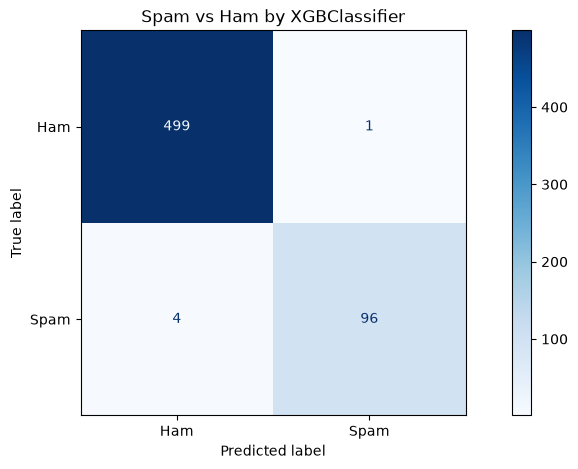

In [46]:
fig, axes = plt.subplots(figsize = (12, 5))

cm = confusion_matrix(y_test, predictions)
cm_pct = confusion_matrix(y_test, predictions, normalize = 'true') * 100


ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Ham', 'Spam']).plot(ax = axes, cmap = 'Blues')
axes.set_title('Spam vs Ham by XGBClassifier')

plt.show()

In [49]:
print(f"True Negative Rate (Specificity): {cm_pct[0, 0]:.2f}%")
print(f"True Positive Rate (Sensitivity): {cm_pct[1, 1]:.2f}%")

True Negative Rate (Specificity): 99.80%
True Positive Rate (Sensitivity): 96.00%


## True Negative Rate <strong>(Specificity)</strong>: 99.80%
## True Positive Rate <strong>(Sensitivity)</strong>: 96.00%

In [22]:
sample_emails = [
    "congratulations you have been selected to receive a free prize worth NUMBER dollars click here now to claim your reward before this offer expires act now limited time only winner",
    "hi john just wanted to follow up on the meeting notes from yesterday can you send over the budget spreadsheet when you get a chance thanks talk soon"
]

In [23]:
predictions_live = grid_search.predict(sample_emails)
predictions_live = map(lambda x: "Spam" if x == 1 else "Ham", predictions_live)
print(list(predictions_live))

['Spam', 'Ham']


In [24]:
sample_emails_2 = [
    "urgent your account has been suspended verify your identity immediately by clicking the link below or lose access permanently free gift included act fast limited offer",
    "hey sarah thanks for sending over the draft i left a few comments in the doc let me know if you have questions before the call tomorrow morning"
]

In [25]:
predictions_live_2 = grid_search.predict(sample_emails_2)
predictions_live_2 = map(lambda x: "Spam" if x == 1 else "Ham", predictions_live_2)
print(list(predictions_live_2))

['Spam', 'Ham']


In [26]:
best_pipeline = grid_search.best_estimator_

In [27]:
model = best_pipeline.named_steps['xgb']
tfidf_fitted = best_pipeline.named_steps['tfidf']
X_test_vectorized = tfidf_fitted.transform(X_test)
feature_names = tfidf_fitted.get_feature_names_out()

In [28]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_vectorized)

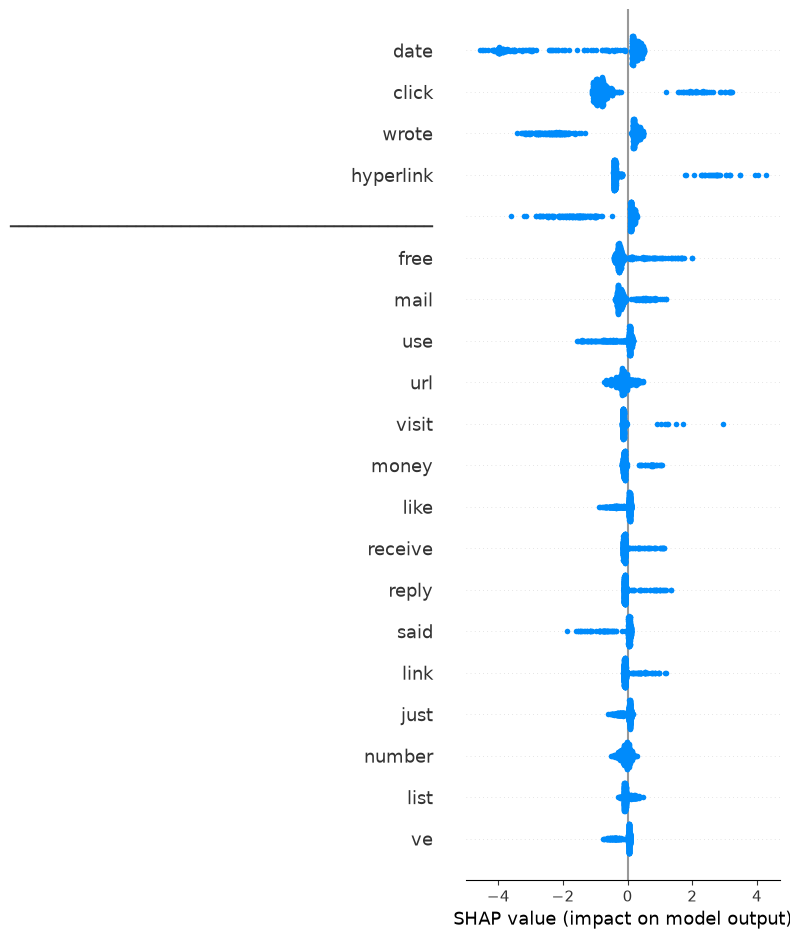

In [29]:
shap.summary_plot(shap_values, feature_names = feature_names, max_display = 20)

In [30]:
sample_email = ["urgent your account has been suspended verify your identity immediately by clicking the link below or lose access permanently free gift included act fast limited offer"]

In [31]:
predict_shap_sample = grid_search.predict(sample_email)
predict_shap_sample = map(lambda x: "Spam" if x == 1 else "Ham", predict_shap_sample)
print(list(predict_shap_sample))

['Spam']


In [32]:
sample_vectorized = tfidf_fitted.transform(sample_email)

In [33]:
sample_shap_values = explainer.shap_values(sample_vectorized)

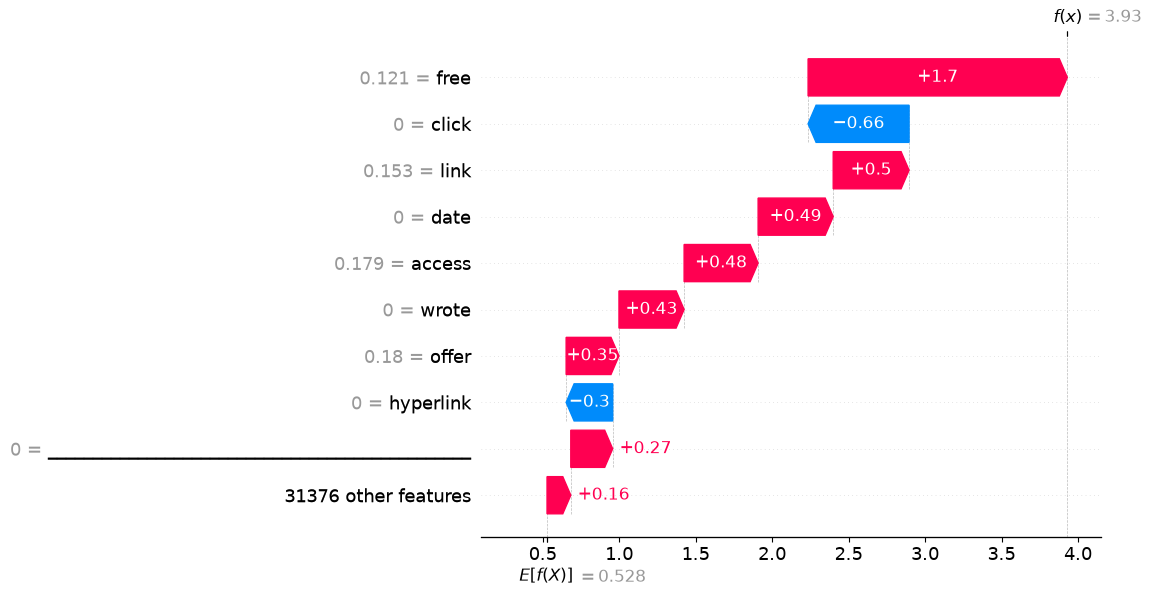

In [34]:
shap.waterfall_plot(
    shap.Explanation(
        values = sample_shap_values[0],
        base_values = explainer.expected_value,
        data = sample_vectorized.toarray()[0],
        feature_names = feature_names
    )
)

In [35]:
sample_email_2 = [
    "hey sarah thanks for sending over the draft i left a few comments in the doc let me know if you have questions before the call tomorrow morning"
]

In [36]:
predict_shap_sample_2 = grid_search.predict(sample_email_2)
predict_shap_sample_2 = map(lambda x: "Spam" if x == 1 else "Ham", predict_shap_sample_2)
print(list(predict_shap_sample_2))

['Ham']


In [37]:
sample_2_vectorized = tfidf_fitted.transform(sample_email_2)

In [38]:
sample_2_shap_values = explainer.shap_values(sample_2_vectorized)

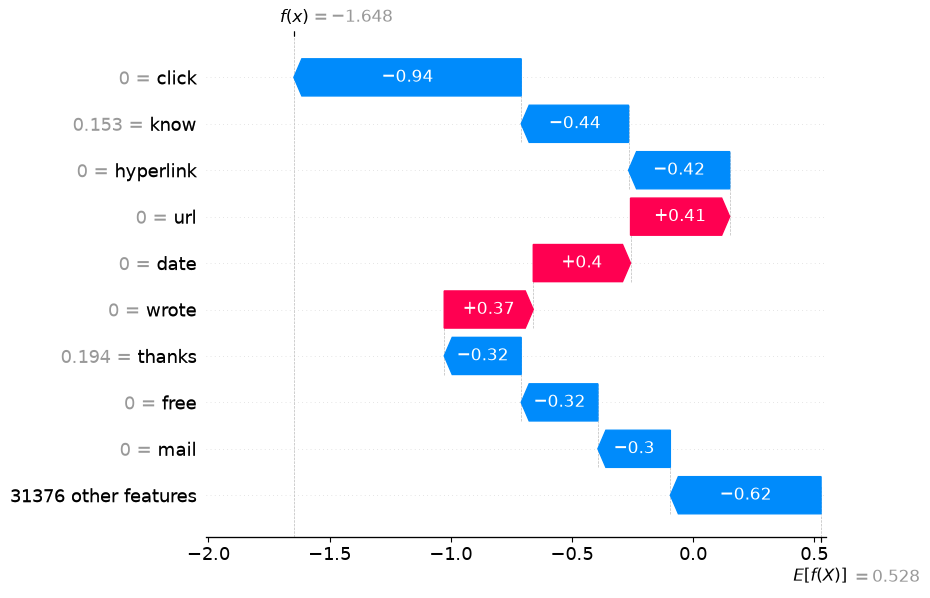

In [39]:
shap.waterfall_plot(
    shap.Explanation(
        values = sample_2_shap_values[0],
        base_values = explainer.expected_value,
        data = sample_2_vectorized.toarray()[0],
        feature_names = feature_names
    )
)